In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error

In [2]:
#path = "/content/drive/MyDrive/dataset/final dataset.csv"
#df = pd.read_csv(path)
df = pd.read_csv("Dataset_histo_NEWS_2017_2023.csv")
#df = df.drop_duplicates(subset=["Date"], keep="first")

In [3]:
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

Columns: ['Date', 'Index', 'volatility', 'Newscore', 'Newsenti']


In [4]:
# 4. DATE HANDLING (DD/MM/YYYY)
# ==============================
df["Date"] = pd.to_datetime(df["Date"],dayfirst=True,errors="coerce")
df = df.dropna(subset=["Date"])
df = df.set_index("Date")
print("Date range:", df.index.min(), "to", df.index.max())

Date range: 2017-01-03 00:00:00 to 2023-12-29 00:00:00


In [5]:
# 5. AUTO-DETECT VOLATILITY COLUMN
# ==============================
vol_col = [c for c in df.columns if "vol" in c.lower()][0]
print("Using volatility column:", vol_col)

Using volatility column: volatility


In [6]:
# 6. PREPARE LOG VOLATILITY
# ==============================
log_vol = df[vol_col].dropna()

# Scale for numerical stability
log_vol = log_vol * 100
print("Observations used:", len(log_vol))

Observations used: 1713


In [7]:
# Clean column names again (safe)
df.columns = df.columns.str.strip()

# Auto-detect volatility column
vol_col = [c for c in df.columns if "vol" in c.lower()][0]
print("Volatility column:", vol_col)

# Convert to numeric (this is the KEY FIX)
df[vol_col] = pd.to_numeric(df[vol_col], errors="coerce")

# Drop invalid values
df = df.dropna(subset=[vol_col])

Volatility column: volatility


In [8]:
print(df[vol_col].dtype)

float64


In [9]:
log_vol = df[vol_col] * 100
log_vol_fast = log_vol

In [10]:
print("Min:", log_vol_fast.min())
print("Max:", log_vol_fast.max())
print("Std:", log_vol_fast.std())
print("Any NaN:", log_vol_fast.isna().any())
print("Any Inf:", np.isinf(log_vol_fast).any())

Min: 0.0123653
Max: 2.8465718
Std: 0.4743861284584946
Any NaN: False
Any Inf: False


In [11]:
best_aic = np.inf
best_order = None
best_model = None

for p in range(1, 11):        # p = 1 to 10
    for q in range(1, 11):    # q = 1 to 10
        print(f"Trying GARCH({p},{q})")

        try:
            model = arch_model(log_vol_fast,mean="Constant",vol="GARCH",p=p,q=q)
            fitted_model = model.fit(disp="off")

            if fitted_model.aic < best_aic:
                best_aic = fitted_model.aic
                best_order = (p, q)
                best_model = fitted_model

        except Exception as e:
            print(f"GARCH({p},{q}) failed: {e}")

print("Best GARCH order:", best_order)
print("Best AIC:", best_aic)

Trying GARCH(1,1)
Trying GARCH(1,2)
Trying GARCH(1,3)
Trying GARCH(1,4)
Trying GARCH(1,5)
Trying GARCH(1,6)
Trying GARCH(1,7)
Trying GARCH(1,8)
Trying GARCH(1,9)
Trying GARCH(1,10)
Trying GARCH(2,1)
Trying GARCH(2,2)
Trying GARCH(2,3)
Trying GARCH(2,4)
Trying GARCH(2,5)
Trying GARCH(2,6)
Trying GARCH(2,7)
Trying GARCH(2,8)
Trying GARCH(2,9)
Trying GARCH(2,10)
Trying GARCH(3,1)
Trying GARCH(3,2)
Trying GARCH(3,3)
Trying GARCH(3,4)
Trying GARCH(3,5)
Trying GARCH(3,6)
Trying GARCH(3,7)
Trying GARCH(3,8)
Trying GARCH(3,9)
Trying GARCH(3,10)
Trying GARCH(4,1)
Trying GARCH(4,2)
Trying GARCH(4,3)
Trying GARCH(4,4)
Trying GARCH(4,5)
Trying GARCH(4,6)
Trying GARCH(4,7)
Trying GARCH(4,8)
Trying GARCH(4,9)
Trying GARCH(4,10)
Trying GARCH(5,1)
Trying GARCH(5,2)
Trying GARCH(5,3)
Trying GARCH(5,4)
Trying GARCH(5,5)
Trying GARCH(5,6)
Trying GARCH(5,7)
Trying GARCH(5,8)
Trying GARCH(5,9)
Trying GARCH(5,10)
Trying GARCH(6,1)
Trying GARCH(6,2)
Trying GARCH(6,3)
Trying GARCH(6,4)
Trying GARCH(6,5)
Tryin

In [12]:
print(best_model.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             volatility   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1035.89
Distribution:                  Normal   AIC:                           2087.77
Method:            Maximum Likelihood   BIC:                           2131.34
                                        No. Observations:                 1713
Date:                Sun, May 10 2026   Df Residuals:                     1712
Time:                        03:38:29   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.7504  2.378e-02     31.557 1.437e-218 [  0.704,  0.79

In [13]:
# 9. CONDITIONAL VOLATILITY
# ==============================
garch_df = pd.DataFrame({"garch_volatility": best_model.conditional_volatility})
garch_vol = np.sqrt(best_model.conditional_volatility)

In [14]:
garch_df["garch_volatility"]

Date
2017-01-03    0.762706
2017-01-04    0.719670
2017-01-05    0.682931
2017-01-06    0.980061
2017-01-10    0.782626
                ...   
2023-12-22    0.370963
2023-12-26    0.346697
2023-12-27    0.353151
2023-12-28    0.333870
2023-12-29    0.332855
Name: garch_volatility, Length: 1713, dtype: float64

In [15]:
garch_vol = best_model.conditional_volatility
garch_vol_norm = (garch_vol - garch_vol.min()) / (garch_vol.max() - garch_vol.min())

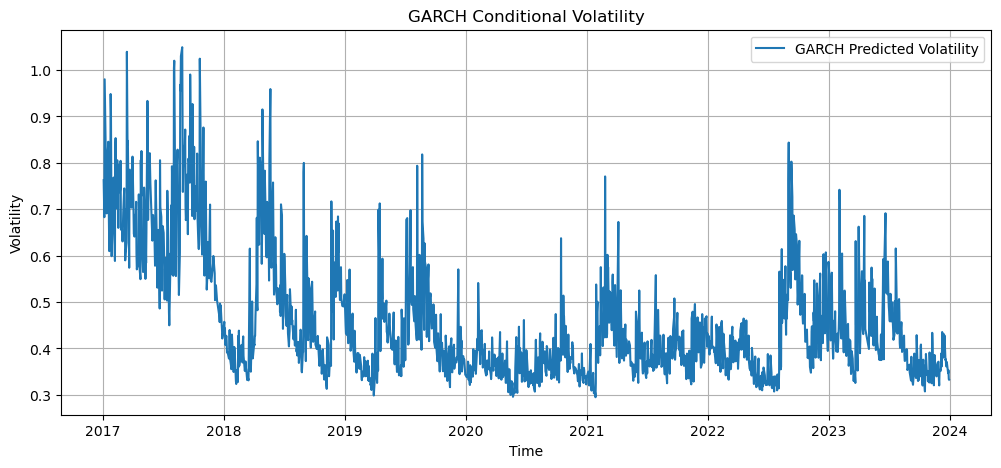

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(log_vol_fast.index, garch_vol, label="GARCH Predicted Volatility")
plt.title("GARCH Conditional Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

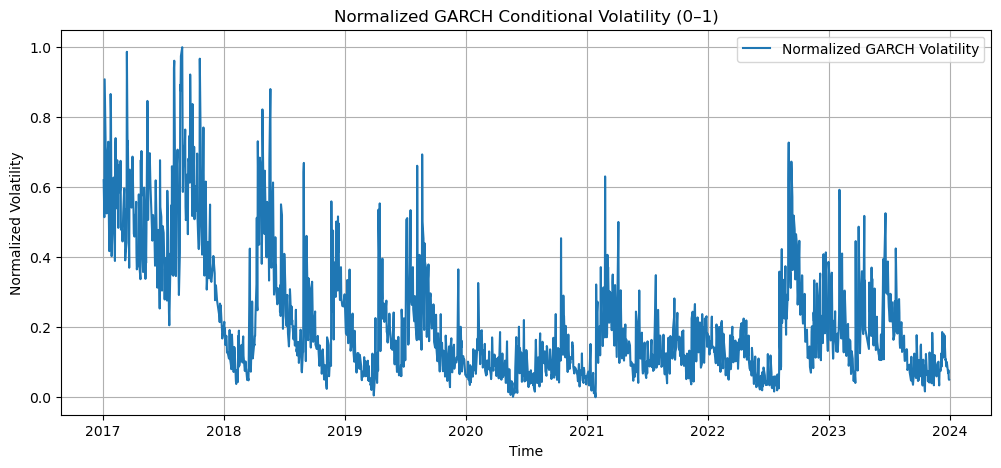

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(log_vol_fast.index,garch_vol_norm,label="Normalized GARCH Volatility")
plt.title("Normalized GARCH Conditional Volatility (0–1)")
plt.xlabel("Time")
plt.ylabel("Normalized Volatility")
plt.legend()
plt.grid(True)
plt.show()

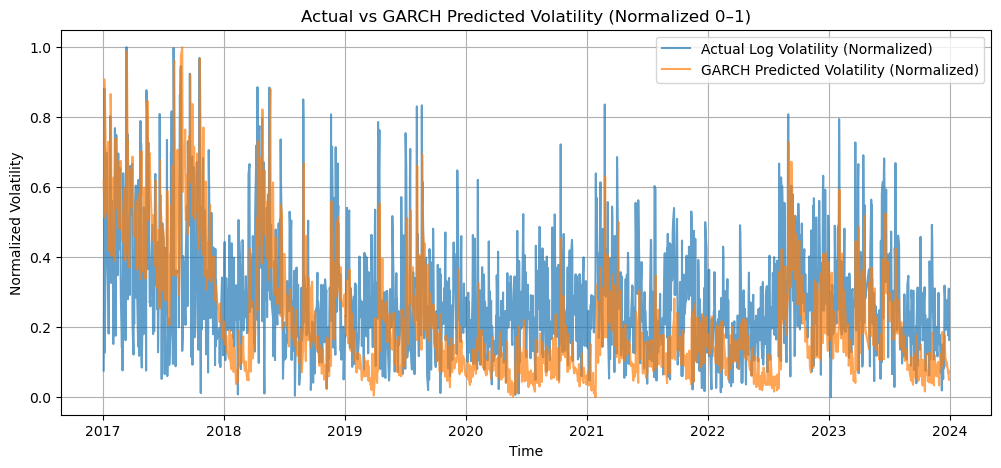

In [18]:
log_vol_norm = (log_vol_fast - log_vol_fast.min()) / (log_vol_fast.max() - log_vol_fast.min())
plt.figure(figsize=(12, 5))
plt.plot(log_vol_fast.index,log_vol_norm,label="Actual Log Volatility (Normalized)",alpha=0.7)
plt.plot(log_vol_fast.index,garch_vol_norm,label="GARCH Predicted Volatility (Normalized)",alpha=0.7)
plt.title("Actual vs GARCH Predicted Volatility (Normalized 0–1)")
plt.xlabel("Time")
plt.ylabel("Normalized Volatility")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
eps = 1e-8
rmse = np.sqrt(mean_squared_error(log_vol_norm, garch_vol_norm))
rmse = np.sqrt(mean_squared_error(log_vol_norm, garch_vol_norm))

In [20]:
actual_var = np.square(log_vol_norm) + eps
pred_var = np.square(garch_vol_norm) + eps
qlike = np.mean(np.log(pred_var) + actual_var / pred_var)

In [21]:
#print(f"R²     : {R2:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"QLIKE  : {qlike:.4f}")

RMSE   : 0.2057
QLIKE  : 7110.8734


In [23]:
garch_df.to_csv("Garch17-23.csv")